In [1]:
import geopandas as gpd
import pandas as pd
df_geo = pd.DataFrame({
    "lat": [59.3293, 59.33, 57.7089, 63.8258],
    "lon": [18.0686, 18.07, 11.9746, 20.2630]
})

gdf_points = gpd.GeoDataFrame(
    df_geo,
    geometry=gpd.points_from_xy(df_geo["lon"], df_geo["lat"]),
    crs="EPSG:4326"
)

gdf_points = gdf_points.to_crs("EPSG:3006")
gdf_points.head()

,lat,lon,geometry
0,59.3293,18.0686,POINT (674571.866 6580743.008)
1,59.3300,18.0700,POINT (674647.882 6580824.576)
2,57.7089,11.9746,POINT (319758.02 6400326.036)
3,63.8258,20.2630,POINT (758803.435 7088280.798)


In [2]:
from grid import create_grid
grid = create_grid(gdf_points, cell_size=5000)
grid.head()

,geometry,cell_id
0,"POLYGON ((324758.02 6400326.036, 324758.02 640...",0
1,"POLYGON ((324758.02 6405326.036, 324758.02 641...",1
2,"POLYGON ((324758.02 6410326.036, 324758.02 641...",2
3,"POLYGON ((324758.02 6415326.036, 324758.02 642...",3
4,"POLYGON ((324758.02 6420326.036, 324758.02 642...",4


In [3]:
from grid import spatial_join_points_to_grid
joined = spatial_join_points_to_grid(gdf_points, grid)
joined.head()

,lat,lon,geometry,index_right,cell_id
0,59.3293,18.0686,POINT (674571.866 6580743.008),9696.0,9696.0
1,59.3300,18.0700,POINT (674647.882 6580824.576),9696.0,9696.0
2,57.7089,11.9746,POINT (319758.02 6400326.036),NaN,NaN
3,63.8258,20.2630,POINT (758803.435 7088280.798),12143.0,12143.0


In [4]:
from grid import compute_grid_risk
risk_table = compute_grid_risk(joined)
risk_table.head()

,cell_id,collision_count,risk
0,9696.0,2,1
1,12143.0,1,0


In [5]:
from grid import build_spatial_grid_pipeline
grid, joined, risk_table = build_spatial_grid_pipeline(gdf_points, cell_size=5000)

<Axes: >

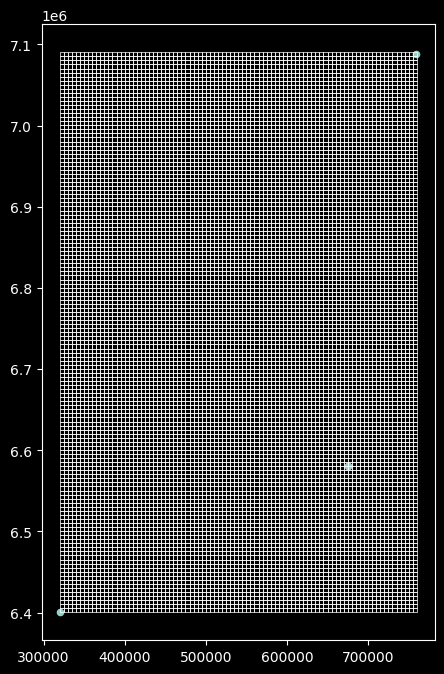

In [6]:
ax = grid.boundary.plot(figsize=(8, 8), linewidth=0.5)
gdf_points.plot(ax=ax, markersize=20)

<Axes: >

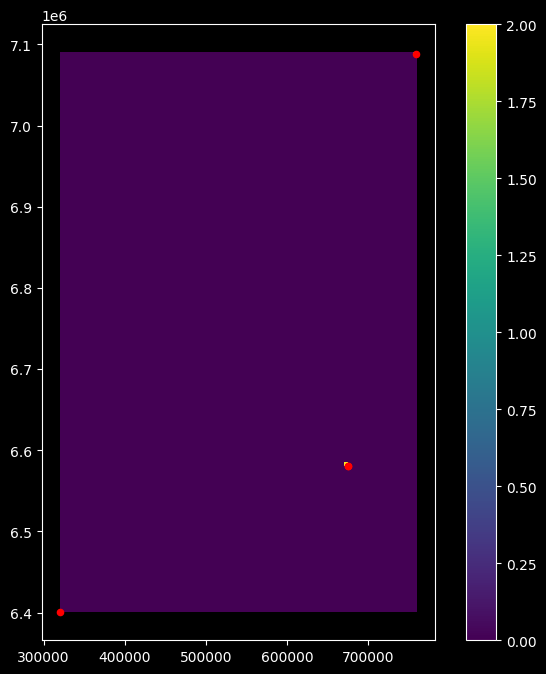

In [7]:
grid_risk = grid.merge(risk_table, on="cell_id", how="left")
grid_risk["collision_count"] = grid_risk["collision_count"].fillna(0)
grid_risk["risk"] = grid_risk["risk"].fillna(0)

ax = grid_risk.plot(column="collision_count", figsize=(8, 8), legend=True)
gdf_points.plot(ax=ax, color="red", markersize=20)